# 4_1. LDA ręcznie: projekcja nadzorowana i intuicja „supervised PCA”

PCA szuka kierunku największej wariancji **bez patrzenia na etykiety**.

LDA (*Linear Discriminant Analysis*) szuka kierunku, który najlepiej rozdziela klasy, czyli używa etykiet `y`.

Dla dwóch klas kierunek Fishera można zapisać jako:

$$
w=S_W^{-1}(\mu_1-\mu_0),
$$

gdzie:

$$
S_W=S_0+S_1
$$

jest rozrzutem wewnątrz klas.

Intuicja: LDA chce znaleźć taką oś, żeby po rzucie klasy były możliwie daleko od siebie, ale punkty tej samej klasy były możliwie blisko siebie.

## Dydaktyczna uwaga do nazwy „supervised PCA”

Określenie **supervised PCA** traktujemy tutaj tylko jako intuicję: LDA też szuka osi projekcji, ale w przeciwieństwie do PCA używa etykiet klas.

Formalnie LDA nie jest PCA z etykietami — optymalizuje inny cel:

$$
J(w)=\frac{w^T S_B w}{w^T S_W w},
$$

czyli chce uzyskać:

```text
duży rozrzut między klasami
mały rozrzut wewnątrz klas
```

To odróżnienie jest ważne, bo PCA może znaleźć kierunek dużej zmienności, który wcale nie musi najlepiej rozdzielać klas.

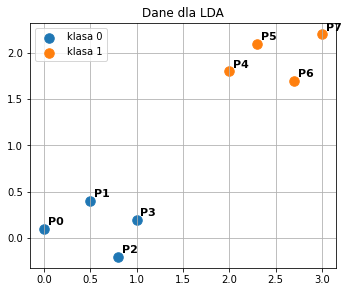

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.precision', 3)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True


def plot_points(X, labels, y=None, title='punkty', annotate=True, ax=None, extra_points=None):
    X = np.asarray(X, dtype=float)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4.5))
    if y is None:
        ax.scatter(X[:, 0], X[:, 1], s=90)
    else:
        y = np.asarray(y)
        for val in np.unique(y):
            mask = y == val
            ax.scatter(X[mask, 0], X[mask, 1], s=90, label=f'klasa {val}')
        ax.legend()
    if annotate:
        for lab, (xv, yv) in zip(labels, X):
            ax.text(xv + 0.04, yv + 0.04, str(lab), fontsize=11, weight='bold')
    if extra_points:
        for lab, pt in extra_points.items():
            ax.scatter([pt[0]], [pt[1]], marker='*', s=160)
            ax.text(pt[0] + 0.06, pt[1] + 0.06, lab, fontsize=12, weight='bold')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax


X = np.array([
    [0.0, 0.1], [0.5, 0.4], [0.8, -0.2], [1.0, 0.2],
    [2.0, 1.8], [2.3, 2.1], [2.7, 1.7], [3.0, 2.2],
])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])
labels = np.array([f'P{i}' for i in range(len(X))])
plot_points(X, labels, y=y, title='Dane dla LDA')
plt.show()

## 1. Średnie klas

Dla każdej klasy liczymy średnią:

$$
\mu_c=\frac{1}{n_c}\sum_{i:y_i=c}x_i.
$$

In [2]:
mu0 = X[y==0].mean(axis=0)
mu1 = X[y==1].mean(axis=0)
display(pd.DataFrame([mu0, mu1], index=['mu0', 'mu1'], columns=['x1','x2']))

,x1,x2
mu0,0.575,0.125
mu1,2.500,1.950


## 2. Macierz rozrzutu wewnątrz klas

Dla klasy $c$:

$$
S_c=\sum_{i:y_i=c}(x_i-\mu_c)(x_i-\mu_c)^T.
$$

Potem:

$$
S_W=S_0+S_1.
$$

In [3]:
def scatter_matrix(Xc, mu):
    Z = Xc - mu
    return Z.T @ Z

S0 = scatter_matrix(X[y==0], mu0)
S1 = scatter_matrix(X[y==1], mu1)
SW = S0 + S1
print('S0')
display(pd.DataFrame(np.round(S0,3), columns=['x1','x2'], index=['x1','x2']))
print('S1')
display(pd.DataFrame(np.round(S1,3), columns=['x1','x2'], index=['x1','x2']))
print('SW')
display(pd.DataFrame(np.round(SW,3), columns=['x1','x2'], index=['x1','x2']))

S0


,x1,x2
x1,0.568,-0.048
x2,-0.048,0.188


S1


,x1,x2
x1,0.58,0.12
x2,0.12,0.17


SW


,x1,x2
x1,1.148,0.072
x2,0.072,0.358


## 3. Kierunek LDA

Liczymy:

$$
w=S_W^{-1}(\mu_1-\mu_0).
$$

Potem normalizujemy wektor, żeby miał długość 1:

$$
\lVert w\rVert=1.
$$

In [4]:
w = np.linalg.solve(SW, (mu1 - mu0))  # stabilniej niż jawne odwracanie macierzy
w = w / np.linalg.norm(w)
display(pd.DataFrame([w], index=['w LDA'], columns=['w1','w2']))

,w1,w2
w LDA,0.274,0.962


## 4. Rzutowanie punktów na prostą LDA

Punkt $x_i$ rzutujemy na kierunek $w$:

$$
z_i=w^T x_i.
$$

Na rysunku poniżej pokazujemy:

- punkty w 2D,
- średnie klas $\mu_0,\mu_1$,
- prostą LDA, czyli kierunek, na który rzutujemy punkty,
- rzuty punktów na tę prostą.

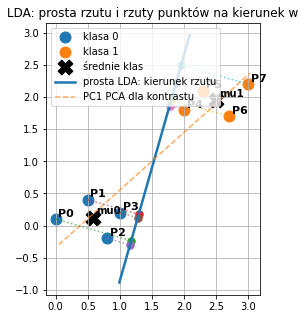

,punkt,klasa,projekcja LDA z_i = w^T x_i
0,P0,0,0.096
1,P1,0,0.522
2,P2,0,0.026
3,P3,0,0.466
4,P4,1,2.278
5,P5,1,2.649
6,P6,1,2.374
7,P7,1,2.937


In [5]:
z = X @ w
origin = X.mean(axis=0)
# rzut na prostą przechodzącą przez origin i mającą kierunek w
proj_scalar = (X - origin) @ w
X_proj = origin + proj_scalar[:, None] * w

# PCA direction as a visual contrast
X_centered = X - X.mean(axis=0)
Cov = X_centered.T @ X_centered / (len(X)-1)
eigvals, eigvecs = np.linalg.eigh(Cov)
pc1 = eigvecs[:, np.argmax(eigvals)]
if pc1 @ w < 0:
    pc1 = -pc1

fig, ax = plt.subplots(figsize=(7,5))
for c in [0,1]:
    idx = y == c
    ax.scatter(X[idx,0], X[idx,1], s=120, label=f'klasa {c}')
for lab, (xv,yv) in zip(labels, X):
    ax.text(xv+0.04, yv+0.04, lab, fontsize=11, weight='bold')
# class means
ax.scatter([mu0[0], mu1[0]], [mu0[1], mu1[1]], marker='X', s=220, c='black', label='średnie klas')
ax.text(mu0[0]+0.05, mu0[1]+0.05, 'mu0', weight='bold')
ax.text(mu1[0]+0.05, mu1[1]+0.05, 'mu1', weight='bold')
# LDA axis and PCA axis
line_t = np.linspace(-2.0, 2.0, 100)
lda_line = origin + line_t[:, None] * w
pca_line = origin + line_t[:, None] * pc1
ax.plot(lda_line[:,0], lda_line[:,1], linewidth=2.5, label='prosta LDA: kierunek rzutu')
ax.plot(pca_line[:,0], pca_line[:,1], linestyle='--', alpha=0.65, label='PC1 PCA dla kontrastu')
# projection segments
for i in range(len(X)):
    ax.plot([X[i,0], X_proj[i,0]], [X[i,1], X_proj[i,1]], linestyle=':', alpha=0.7)
    ax.scatter([X_proj[i,0]], [X_proj[i,1]], s=55, marker='o')
ax.set_title('LDA: prosta rzutu i rzuty punktów na kierunek w')
ax.set_aspect('equal', adjustable='box')
ax.legend(loc='best')
plt.show()

display(pd.DataFrame({'punkt': labels, 'klasa': y, 'projekcja LDA z_i = w^T x_i': np.round(z,3)}))

## 5. Projekcja 2D → 1D

Po rzutowaniu mamy już tylko jedną liczbę dla każdego punktu:

$$
z_i=w^Tx_i.
$$

W tym jednym wymiarze możemy ustawić prosty próg klasyfikacyjny.

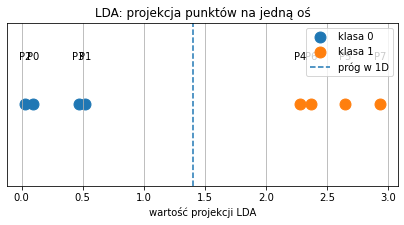

In [6]:
fig, ax = plt.subplots(figsize=(7,3))
for c in [0,1]:
    idx = y==c
    ax.scatter(z[idx], np.zeros(idx.sum()), s=120, label=f'klasa {c}')
    for lab, zz in zip(labels[idx], z[idx]):
        ax.text(zz, 0.03, lab, ha='center')
threshold = (z[y==0].max() + z[y==1].min()) / 2
ax.axvline(threshold, linestyle='--', label='próg w 1D')
ax.set_yticks([])
ax.set_xlabel('wartość projekcji LDA')
ax.set_title('LDA: projekcja punktów na jedną oś')
ax.legend()
plt.show()

## 5b. Od projekcji do klasyfikacji: próg i macierz pomyłek

LDA może być używana na dwa sposoby:

```text
projekcja / redukcja wymiaru  → dostajemy nowe cechy, np. z = w^T x,
klasyfikator                 → dostajemy przewidywaną klasę y_hat.
```

**Macierz pomyłek** ma sens wtedy, gdy mamy prawdziwe etykiety `y` i predykcje modelu `y_pred`.

Wiersze macierzy to zwykle klasy prawdziwe, a kolumny to klasy przewidziane:

| | predykcja 0 | predykcja 1 |
|---|---:|---:|
| prawdziwa 0 | dobrze rozpoznane z klasy 0 | klasa 0 pomylona z 1 |
| prawdziwa 1 | klasa 1 pomylona z 0 | dobrze rozpoznane z klasy 1 |

Poniżej ustawiamy prosty próg na projekcji 1D. To jest dydaktyczna wersja klasyfikatora: punkt po jednej stronie progu dostaje klasę 0, po drugiej klasę 1.

Uwaga: oceniamy tu te same punkty, na których liczyliśmy kierunek LDA, więc to nie jest uczciwy test generalizacji. Chodzi tylko o pokazanie, jak z projekcji przechodzimy do klasyfikacji i jak czytać macierz pomyłek.

,punkt,projekcja z=w^T x,prawdziwa klasa y,predykcja y_hat,czy poprawnie?
0,P0,0.096,0,0,True
1,P1,0.522,0,0,True
2,P2,0.026,0,0,True
3,P3,0.466,0,0,True
4,P4,2.278,1,1,True
5,P5,2.649,1,1,True
6,P6,2.374,1,1,True
7,P7,2.937,1,1,True


Accuracy na tym małym przykładzie: 1.0


,pred 0,pred 1
true 0,4,0
true 1,0,4


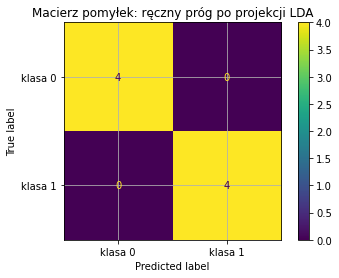

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Dla bezpieczeństwa sprawdzamy, po której stronie progu średnio leży klasa 1.
class1_on_right = z[y == 1].mean() > z[y == 0].mean()
if class1_on_right:
    y_pred_manual = (z >= threshold).astype(int)
else:
    y_pred_manual = (z < threshold).astype(int)

classification_table = pd.DataFrame({
    'punkt': labels,
    'projekcja z=w^T x': np.round(z, 3),
    'prawdziwa klasa y': y,
    'predykcja y_hat': y_pred_manual,
    'czy poprawnie?': y_pred_manual == y,
})
display(classification_table)

cm = confusion_matrix(y, y_pred_manual, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['true 0', 'true 1'], columns=['pred 0', 'pred 1'])
print('Accuracy na tym małym przykładzie:', round(accuracy_score(y, y_pred_manual), 3))
display(cm_df)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['klasa 0', 'klasa 1']).plot()
plt.title('Macierz pomyłek: ręczny próg po projekcji LDA')
plt.show()

## 5c. Interaktywny panel: obracamy kierunek projekcji

LDA można intuicyjnie pokazać jako szukanie takiej osi, na której klasy po rzucie są daleko od siebie, ale każda klasa osobno jest możliwie zwarta.

Dla kierunku $v_\theta$ liczymy prosty wskaźnik Fishera:

$$
J(\theta)=\frac{(m_1-m_0)^2}{s_0^2+s_1^2},
$$

gdzie $m_c$ i $s_c^2$ liczymy po projekcji punktów klasy $c$ na oś $v_\theta$.

Suwak pokazuje, dlaczego kierunek LDA nie musi być tym samym kierunkiem co PC1 z PCA.

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

html_dir = Path('../html')
html_dir.mkdir(parents=True, exist_ok=True)

angles = np.linspace(0, 180, 37)
origin = X.mean(axis=0)
span = np.linalg.norm(X - origin, axis=1).max() + 0.8
lda_angle = (np.degrees(np.arctan2(w[1], w[0])) % 180)
active_idx = int(np.argmin(np.abs(angles - lda_angle)))

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('kierunek projekcji w 2D', 'projekcja na jedną oś'),
    specs=[[{'type': 'scatter'}, {'type': 'scatter'}]],
    column_widths=[0.55, 0.45]
)

for c in [0, 1]:
    mask = y == c
    fig.add_trace(go.Scatter(x=X[mask, 0], y=X[mask, 1], mode='markers+text', text=labels[mask],
                             textposition='top center', marker=dict(size=12), name=f'klasa {c}'), row=1, col=1)

scores_J = []
for idx, angle in enumerate(angles):
    theta = np.deg2rad(angle)
    v = np.array([np.cos(theta), np.sin(theta)])
    z_theta = (X - origin) @ v
    m0, m1 = z_theta[y == 0].mean(), z_theta[y == 1].mean()
    s0 = np.sum((z_theta[y == 0] - m0) ** 2)
    s1 = np.sum((z_theta[y == 1] - m1) ** 2)
    J = float((m1 - m0) ** 2 / (s0 + s1 + 1e-12))
    scores_J.append(J)
    line = np.vstack([origin - span * v, origin + span * v])
    visible = idx == active_idx
    fig.add_trace(go.Scatter(x=line[:, 0], y=line[:, 1], mode='lines', line=dict(width=3),
                             visible=visible, name='oś projekcji', showlegend=False), row=1, col=1)
    for c in [0, 1]:
        mask = y == c
        fig.add_trace(go.Scatter(x=z_theta[mask], y=np.zeros(mask.sum()) + 0.08 * c,
                                 mode='markers+text', text=labels[mask], textposition='top center',
                                 marker=dict(size=12), visible=visible, name=f'projekcja klasy {c}', showlegend=False), row=1, col=2)

base = 2
steps = []
for idx, angle in enumerate(angles):
    visible = [True] * base + [False] * (3 * len(angles))
    for j in range(3):
        visible[base + 3 * idx + j] = True
    steps.append(dict(
        method='update',
        label=f'{angle:.0f}°',
        args=[{'visible': visible}, {'title': f'Kierunek theta={angle:.0f}°, J(theta)={scores_J[idx]:.3f}; LDA≈{lda_angle:.1f}°'}]
    ))

fig.update_layout(
    title=f'LDA: maksimum separacji w pobliżu kierunku LDA ({lda_angle:.1f}°)',
    sliders=[dict(active=active_idx, currentvalue={'prefix': 'theta = '}, steps=steps)],
    height=520
)
fig.update_xaxes(scaleanchor='y', scaleratio=1, row=1, col=1)
fig.update_yaxes(showticklabels=False, row=1, col=2)
fig.write_html(html_dir / '4_1_lda_obracanie_kierunku_projection_slider.html', include_plotlyjs='cdn')
print('Interaktywny wykres zapisano jako HTML. W Jupyter można odkomentować fig.show(), żeby zobaczyć suwak inline.')
# fig.show()

Interaktywny wykres zapisano jako HTML. W Jupyter można odkomentować fig.show(), żeby zobaczyć suwak inline.


## 6. Co warto obserwować na rysunku?

Na rysunku LDA szczególnie ważne są cztery elementy:

1. **prosta LDA** — to oś, na którą rzutujemy punkty,
2. **średnie klas** — LDA chce je rozsunąć po projekcji,
3. **odcinki rzutu** — pokazują, jak punkt 2D staje się liczbą 1D,
4. **PCA dla kontrastu** — PCA może wskazać inny kierunek, bo nie patrzy na etykiety.

Intuicja:

```text
PCA: znajdź kierunek dużej wariancji.
LDA: znajdź kierunek dobrej separacji klas.
```

## 7. Kontrola z `sklearn`: czy ręczny kierunek zgadza się z LDA?

Dobrze jest na końcu sprawdzić ręczne rachunki z gotową implementacją. Kierunek może mieć przeciwny znak, bo oś projekcji można odwrócić bez zmiany sensu klasyfikacji.

Uwaga: próg użyty wyżej, czyli środek między skrajnymi projekcjami klas, działa tu dlatego, że przykład jest czysty i separowalny. W praktyce próg/priory/probabilistyczną decyzję wyznacza model uczony na danych treningowych.

W praktycznym projekcie macierz pomyłek liczylibyśmy na oddzielnym zbiorze testowym. Tutaj celowo robimy ją na małym zbiorze uczącym, bo notebook tłumaczy geometrię LDA krok po kroku.

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_sklearn = LinearDiscriminantAnalysis(n_components=1)
z_sklearn = lda_sklearn.fit_transform(X, y).ravel()

# Znak osi jest umowny. Odwracamy go tylko po to, żeby porównanie było czytelne.
if np.corrcoef(z, z_sklearn)[0, 1] < 0:
    z_sklearn = -z_sklearn

comparison = pd.DataFrame({
    'punkt': labels,
    'klasa': y,
    'projekcja ręczna': np.round(z, 3),
    'projekcja sklearn, po ewentualnym odwróceniu znaku': np.round(z_sklearn, 3),
})
display(comparison)

print('Kierunek ręczny w:', np.round(w, 3))
print('Współczynniki sklearn:', np.round(lda_sklearn.coef_[0] / np.linalg.norm(lda_sklearn.coef_[0]), 3))

,punkt,klasa,projekcja ręczna,"projekcja sklearn, po ewentualnym odwróceniu znaku"
0,P0,0,0.096,-4.803
1,P1,0,0.522,-3.258
2,P2,0,0.026,-5.056
3,P3,0,0.466,-3.460
4,P4,1,2.278,3.124
5,P5,1,2.649,4.470
6,P6,1,2.374,3.470
7,P7,1,2.937,5.515


Kierunek ręczny w: [0.274 0.962]
Współczynniki sklearn: [0.274 0.962]
